¿Qué hace una CNN?

Una  CNN:  Detecta  bordes,  aprende  texturas,Identifica  formas,  clasifica
objetos
Las CNN utilizan:  Convoluciones, poolin, capas densas
Una CNN es una red neuronal diseñada para procesar imágenes de forma jerárquica, pasando de detectar características simples como bordes y texturas en las primeras capas, hasta identificar formas complejas y clasificar objetos en las capas finales. Este proceso es similar al sistema visual humano, donde la corteza visual procesa la información de lo simple a lo complejo.

In [1]:
# 2)  Importar librerías , Stanford Dogs
import tensorflow as tf
import tensorflow_datasets as tfds
from tensorflow.keras import layers, models
from tensorflow.keras.applications import EfficientNetB3
from tensorflow.keras.applications.efficientnet import preprocess_input
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

In [2]:
# 3)  Cargar dataset
IMG_SIZE = 224
SELECTED_LABELS = [0, 1, 2, 3, 4]
CLASS_NAMES     = ['Chihuahua', 'Japanese Spaniel', 'Maltese', 'Pekinese', 'Shih-Tzu']
label_map = {orig: new for new, orig in enumerate(SELECTED_LABELS)}

In [3]:
print("Cargando Stanford Dogs...")

ds_full, info = tfds.load(
    'stanford_dogs',
    split='train+test',
    as_supervised=True,
    with_info=True
)

# Filtrar las 5 clases
images_list, labels_list = [], []

for image, label in ds_full:
    label_val = label.numpy()
    if label_val in SELECTED_LABELS:
        image = tf.image.resize(image, [IMG_SIZE, IMG_SIZE]).numpy().astype('float32')
        images_list.append(image)
        labels_list.append(label_map[label_val])

images_all = np.array(images_list)
labels_all = np.array(labels_list)

print(f"Total imágenes filtradas: {len(images_all)}")
print(f"Shape: {images_all.shape}")

# Mezclar datos
idx        = np.random.permutation(len(images_all))
images_all = images_all[idx]
labels_all = labels_all[idx]

# Split 80 / 20
split        = int(len(images_all) * 0.80)
train_images = images_all[:split]
train_labels = labels_all[:split]
test_images  = images_all[split:]
test_labels  = labels_all[split:]

print(f"Train: {len(train_images)} | Test: {len(test_images)}")

Cargando Stanford Dogs...


Dl Completed...: 0 url [00:00, ? url/s]

Dl Size...: 0 MiB [00:00, ? MiB/s]

Dl Completed...: 0 url [00:00, ? url/s]

Dl Size...: 0 MiB [00:00, ? MiB/s]

...

Generating train examples...: 0 examples [00:00, ? examples/s]

Shuffling /root/tensorflow_datasets/stanford_dogs/incomplete.PM2BO3_0.2.0/stanford_dogs-train.tfrecord-[0-9][0…

Generating test examples...: 0 examples [00:00, ? examples/s]

Shuffling /root/tensorflow_datasets/stanford_dogs/incomplete.PM2BO3_0.2.0/stanford_dogs-test.tfrecord-[0-9][0-…

Dataset stanford_dogs downloaded and prepared to /root/tensorflow_datasets/stanford_dogs/0.2.0. Subsequent calls will reuse this data.
Total imágenes filtradas: 952
Shape: (952, 224, 224, 3)
Train: 761 | Test: 191


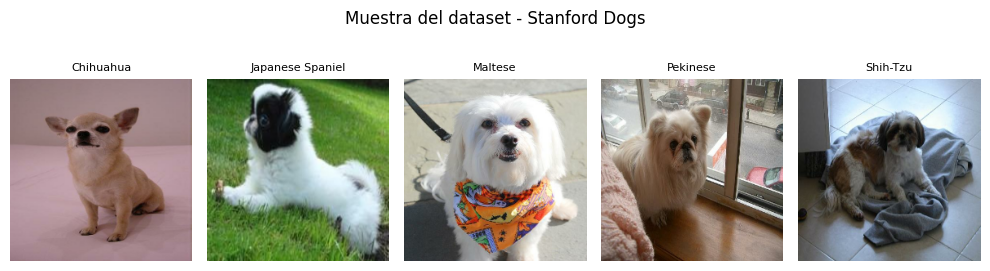

In [4]:
# 4)  Explorar datos
plt.figure(figsize=(10, 3))
for i, nombre in enumerate(CLASS_NAMES):
    idx_raza = np.where(train_labels == i)[0][0]
    plt.subplot(1, 5, i + 1)
    plt.imshow(train_images[idx_raza].astype('uint8'))
    plt.title(nombre, fontsize=8)
    plt.axis('off')
plt.suptitle('Muestra del dataset - Stanford Dogs', fontsize=12)
plt.tight_layout()
plt.show()

Chihuahua           : 152 imágenes
Japanese Spaniel    : 185 imágenes
Maltese             : 252 imágenes
Pekinese            : 149 imágenes
Shih-Tzu            : 214 imágenes


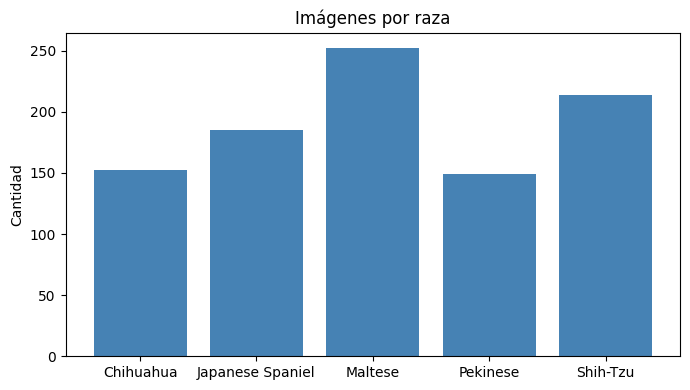

In [5]:
for i, nombre in enumerate(CLASS_NAMES):
    cantidad = np.sum(labels_all == i)
    print(f"{nombre:<20}: {cantidad} imágenes")
conteos = [np.sum(labels_all == i) for i in range(len(CLASS_NAMES))]

plt.figure(figsize=(7, 4))
plt.bar(CLASS_NAMES, conteos, color='steelblue')
plt.title('Imágenes por raza')
plt.ylabel('Cantidad')
plt.tight_layout()
plt.show()

In [6]:
 # 5)  Preprocesamiento
 # Normalización
train_images = images_all[:split]
test_images  = images_all[split:]

print("Shape train:", train_images.shape)
print("Shape test :", test_images.shape)


Shape train: (761, 224, 224, 3)
Shape test : (191, 224, 224, 3)


In [7]:
from tensorflow.keras.applications.efficientnet import preprocess_input

train_images_eff = preprocess_input(train_images.copy())  # valores en 0-255
test_images_eff  = preprocess_input(test_images.copy())

In [8]:
# 6)  Construcción de la CNN
base_model = EfficientNetB3(
    weights     = 'imagenet',
    include_top = False,
    input_shape = (IMG_SIZE, IMG_SIZE, 3)
)
base_model.trainable = False
data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.2),
    layers.RandomZoom(0.2),
    layers.RandomContrast(0.2),
    layers.RandomBrightness(0.1),
])
inputs  = tf.keras.Input(shape=(IMG_SIZE, IMG_SIZE, 3))
x       = data_augmentation(inputs)
x       = base_model(x, training=False)
x       = layers.GlobalAveragePooling2D()(x)
x       = layers.BatchNormalization()(x)
x       = layers.Dense(256, activation='relu')(x)
x       = layers.Dropout(0.4)(x)
outputs = layers.Dense(5, activation='softmax')(x)

model = tf.keras.Model(inputs, outputs)

43941136/43941136 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [9]:
#  7)  Visualizar arquitectura
model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential (Sequential)         │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetb3 (Functional)     │ (None, 7, 7, 1536)     │    10,783,535 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1536)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 1536)           │         6,144 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       393,472 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 5)              │         1,285 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,184,436 (42.67 MB)

 Trainable params: 397,829 (1.52 MB)

 Non-trainable params: 10,786,607 (41.15 MB)

In [10]:
#  8)  Compilar modelo
early_stop = tf.keras.callbacks.EarlyStopping(
    monitor              = 'val_accuracy',
    patience             = 6,
    restore_best_weights = True
)

reduce_lr = tf.keras.callbacks.ReduceLROnPlateau(
    monitor  = 'val_loss',
    factor   = 0.3,
    patience = 3,
    min_lr   = 1e-7,
    verbose  = 1
)
model.compile(
    optimizer = tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss      = 'sparse_categorical_crossentropy',
    metrics   = ['accuracy']
)

In [11]:
# 9)  Entrenar modelo
history_1 = model.fit(
    train_images_eff, train_labels,
    epochs          = 15,
    validation_data = (test_images_eff, test_labels),
    callbacks       = [early_stop, reduce_lr]
)

Epoch 1/15
24/24 ━━━━━━━━━━━━━━━━━━━━ 32s 454ms/step - accuracy: 0.7648 - loss: 0.7715 - val_accuracy: 0.9424 - val_loss: 0.2283 - learning_rate: 0.0010
Epoch 2/15
24/24 ━━━━━━━━━━━━━━━━━━━━ 4s 176ms/step - accuracy: 0.9185 - loss: 0.2960 - val_accuracy: 0.9529 - val_loss: 0.1944 - learning_rate: 0.0010
Epoch 3/15
24/24 ━━━━━━━━━━━━━━━━━━━━ 4s 175ms/step - accuracy: 0.9277 - loss: 0.2450 - val_accuracy: 0.9476 - val_loss: 0.1478 - learning_rate: 0.0010
Epoch 4/15
24/24 ━━━━━━━━━━━━━━━━━━━━ 4s 174ms/step - accuracy: 0.9317 - loss: 0.2081 - val_accuracy: 0.9581 - val_loss: 0.1286 - learning_rate: 0.0010
Epoch 5/15
24/24 ━━━━━━━━━━━━━━━━━━━━ 4s 168ms/step - accuracy: 0.9238 - loss: 0.2587 - val_accuracy: 0.9581 - val_loss: 0.1281 - learning_rate: 0.0010
Epoch 6/15
24/24 ━━━━━━━━━━━━━━━━━━━━ 5s 210ms/step - accuracy: 0.9435 - loss: 0.2138 - val_accuracy: 0.9634 - val_loss: 0.1288 - learning_rate: 0.0010
Epoch 7/15
24/24 ━━━━━━━━━━━━━━━━━━━━ 4s 169ms/step - accuracy: 0.9396 - loss: 0.1687 -

In [12]:
# 10)  Evaluar desempeño
test_loss, test_acc = model.evaluate(test_images, test_labels)
print("Loss    :", test_loss)
print("Accuracy:", test_acc)

6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 134ms/step - accuracy: 0.9634 - loss: 0.1288
Loss    : 0.12878037989139557
Accuracy: 0.963350772857666


6/6 ━━━━━━━━━━━━━━━━━━━━ 8s 763ms/step


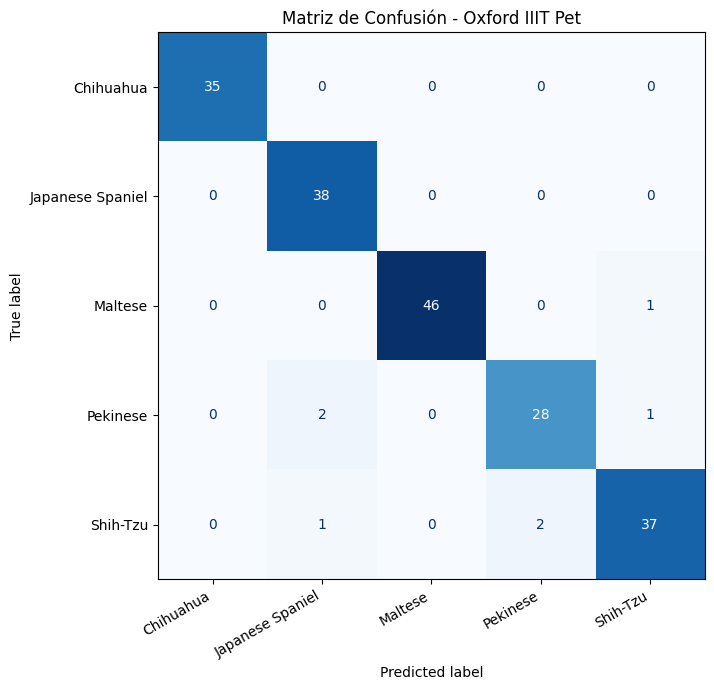

In [13]:
# Matriz de confusión
predictions_all = np.argmax(model.predict(test_images), axis=1)

cm = confusion_matrix(test_labels, predictions_all)
disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                               display_labels=CLASS_NAMES)
fig, ax = plt.subplots(figsize=(8, 7))
disp.plot(ax=ax, cmap='Blues', colorbar=False)
plt.title('Matriz de Confusión - Oxford IIIT Pet')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.show()

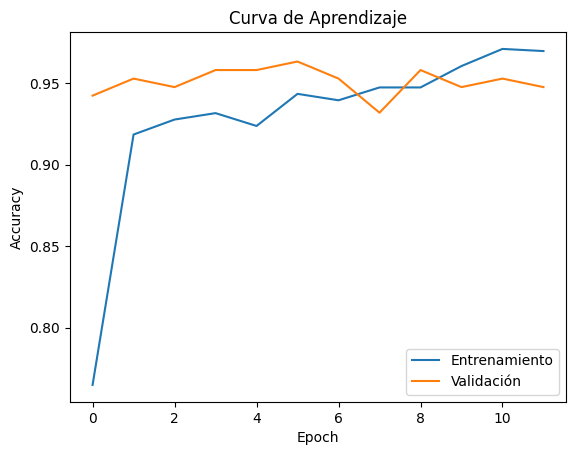

In [16]:
plt.plot(history_1.history['accuracy'],     label='Entrenamiento')
plt.plot(history_1.history['val_accuracy'], label='Validación')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Curva de Aprendizaje')
plt.legend()
plt.show()

6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 141ms/step


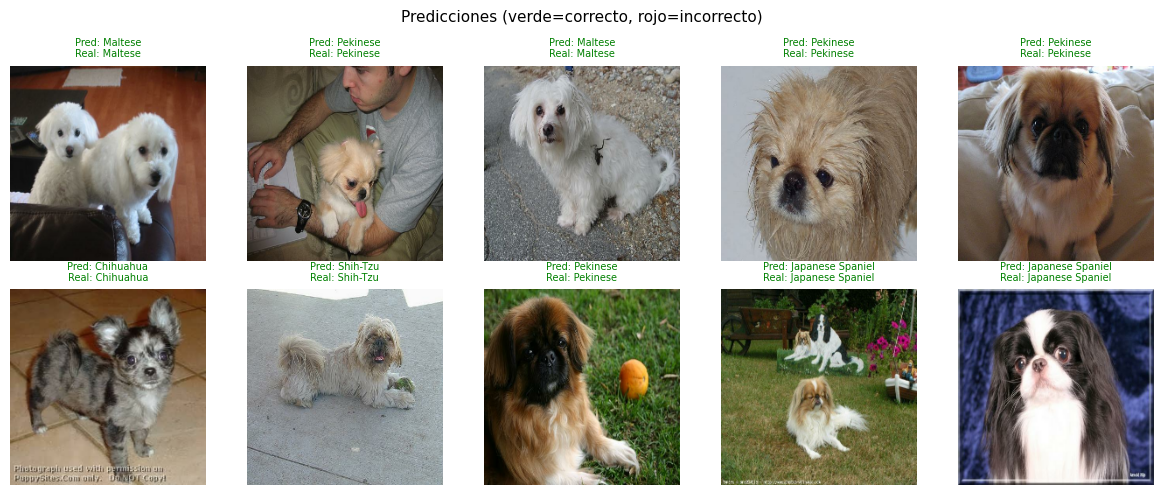

In [17]:
# 12) Predicción de imágenes
predictions = model.predict(test_images_eff)
plt.figure(figsize=(12, 5))
for i in range(10):
    plt.subplot(2, 5, i + 1)
    plt.imshow(test_images[i].astype('uint8'))
    pred  = CLASS_NAMES[np.argmax(predictions[i])]
    real  = CLASS_NAMES[test_labels[i]]
    color = 'green' if pred == real else 'red'
    plt.title(f'Pred: {pred}\nReal: {real}', fontsize=7, color=color)
    plt.axis('off')
plt.suptitle('Predicciones (verde=correcto, rojo=incorrecto)', fontsize=11)
plt.tight_layout()
plt.show()

Selecciona las imágenes de tu computadora:


Saving Pastor aleman.webp to Pastor aleman (1).webp

=== PREDICCIONES CON IMÁGENES SUBIDAS ===


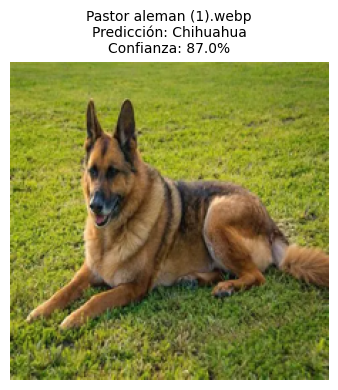


Pastor aleman (1).webp
  Chihuahua                : 87.0%
  Japanese Spaniel         : 1.7%
  Maltese                  : 0.7%
  Pekinese                 : 2.1%
  Shih-Tzu                 : 8.5%


In [21]:
import requests
from PIL import Image
from io import BytesIO
from google.colab import files
from tensorflow.keras.applications.efficientnet import preprocess_input

# ── Subir imágenes desde tu computadora ──────────────────────
print("Selecciona las imágenes de tu computadora:")
uploaded = files.upload()

def predecir_imagen(img, titulo=''):
    # Preprocesamiento igual que en entrenamiento
    img_array  = np.array(img.resize((IMG_SIZE, IMG_SIZE))).astype('float32')
    img_pre    = preprocess_input(img_array.copy())
    img_tensor = np.expand_dims(img_pre, axis=0)

    pred       = model.predict(img_tensor, verbose=0)[0]
    clase_pred = CLASS_NAMES[np.argmax(pred)]
    confianza  = np.max(pred) * 100

    plt.figure(figsize=(4, 4))
    plt.imshow(img_array.astype('uint8'))
    plt.title(f'{titulo}\nPredicción: {clase_pred}\nConfianza: {confianza:.1f}%',
              fontsize=10)
    plt.axis('off')
    plt.tight_layout()
    plt.show()

    print(f"\n{titulo}")
    for i, nombre in enumerate(CLASS_NAMES):
        print(f"  {nombre:<25}: {pred[i]*100:.1f}%")


print("\n=== PREDICCIONES CON IMÁGENES SUBIDAS ===")
for nombre_archivo, contenido in uploaded.items():
    img = Image.open(BytesIO(contenido)).convert('RGB')
    predecir_imagen(img, titulo=nombre_archivo)

* ¿Qué aprende una CNN en las primeras capas?

En las primeras capas la CNN aprende características simples y básicas de las imágenes:

Bordes y líneas en distintas direcciones (horizontal, vertical, diagonal)
Colores y gradientes de intensidad
Texturas simples como pelo, pelaje, patrones

A medida que avanza hacia capas más profundas aprende cosas más complejas como orejas, ojos, hocicos, hasta llegar a reconocer la raza completa.

* ¿Por qué la convolución es importante?

La convolución permite detectar características sin importar dónde aparezcan en la imagen. Por ejemplo, detecta una oreja de beagle esté en la esquina izquierda o derecha de la foto. Además reduce drásticamente el número de parámetros comparado con una red densa tradicional, haciendo el modelo más eficiente y menos propenso a overfitting.

* ¿Cómo se relaciona esta red con percepción humana?

El sistema visual humano y una CNN procesan las imágenes de forma jerárquica, es decir, van de lo simple a lo complejo. Cuando una persona ve un gato, sus ojos no reconocen el animal de golpe, sino que el cerebro primero detecta bordes y contrastes, luego identifica formas como orejas o bigotes, y finalmente integra toda esa información para reconocer que es un gato. Una CNN hace exactamente lo mismo pero de forma computacional.En el cerebro humano, la corteza visual primaria V1 se encarga de detectar bordes y orientaciones básicas, lo que corresponde directamente a las primeras capas Conv2D de VGG16 que aprenden filtros de bordes horizontales, verticales y diagonales. Luego la corteza V2 y V4 combinan esos bordes para formar texturas y formas más complejas, igual que las capas intermedias de la red que aprenden texturas como el pelaje de un beagle o las manchas de un gato bengal.



* ¿Qué limitaciones tiene el modelo?

Pocas imágenes: Oxford Pet tiene ~200 imágenes por raza, lo cual es insuficiente para un modelo robusto
Overfitting: el modelo memoriza el entrenamiento (95%) pero generaliza mal en test (55%)
Solo reconoce 5 razas: cualquier otra raza será clasificada erróneamente como una de las 5
Sensible a la calidad de imagen: fondos complejos, mala iluminación o ángulos inusuales reducen la precisión
Tamaño del modelo: VGG16 tiene 138 millones de parámetros, lo que lo hace pesado para dispositivos móviles o con recursos limitados

7.  Preguntas de Control:

●  ¿Qué función cumple una capa
convolucional?

Una capa convolucional aplica un filtro o kernel sobre la imagen deslizándose píxel a píxel para detectar características específicas como bordes, texturas o formas. En nuestro modelo VGG16 las primeras capas convolucionales detectan características simples como los bordes del pelaje de un beagle o las manchas de un gato bengal, mientras que las capas más profundas combinan esas características simples para reconocer estructuras más complejas como orejas, ojos o el contorno completo del animal.

●  ¿Qué hace el MaxPooling?

MaxPooling reduce el tamaño espacial de la imagen tomando únicamente el valor máximo de cada región. Por ejemplo con un MaxPooling de 2×2 una imagen de 224×224 se convierte en 112×112, quedándose solo con las características más relevantes y descartando información redundante. Esto tiene dos beneficios principales: reduce la cantidad de parámetros del modelo haciéndolo más eficiente, y hace que el modelo sea más tolerante a pequeñas variaciones en la posición del objeto dentro de la imagen.


●  ¿Por qué se normalizan imágenes?


Las imágenes originalmente tienen valores de píxeles entre 0 y 255. Al dividir entre 255 se obtienen valores entre 0 y 1, lo que tiene varias ventajas. Primero el modelo converge más rápido durante el entrenamiento porque los gradientes son más estables. Segundo evita que píxeles con valores muy altos dominen el aprendizaje. En nuestro código esto se hizo con:
train_images = train_images / 255.0
test_images  = test_images  / 255.0


●  ¿Qué representa accuracy?

El accuracy representa el porcentaje de imágenes que el modelo clasificó correctamente. Por ejemplo si el modelo predijo correctamente 90 de 100 imágenes el accuracy es 90%. En nuestro experimento obtuvimos 95% en entrenamiento pero solo 55% en test, lo que indica overfitting: el modelo aprendió bien los datos de entrenamiento pero no generalizó correctamente a imágenes nuevas.


●  ¿Qué diferencia existe entre una CNN y filtros tradicionales?

Los filtros tradicionales como Sobel o Gaussian son diseñados manualmente por expertos y solo detectan características específicas y fijas como bordes horizontales o suavizado de ruido. Una CNN en cambio aprende automáticamente los mejores filtros para cada tarea durante el entrenamiento. En nuestro caso VGG16 aprendió filtros específicos para distinguir el pelaje de un birman del de un boxer sin que nadie le dijera cómo hacerlo, simplemente ajustando sus pesos con cada imagen que procesó.



●  ¿Cómo aprende una CNN?

Una CNN aprende mediante un proceso llamado backpropagation junto con un optimizador, en nuestro caso Adam. El proceso funciona así: primero la red hace una predicción sobre una imagen, luego compara esa predicción con la etiqueta real usando la función de pérdida sparse categorical crossentropy, calcula el error y lo propaga hacia atrás por todas las capas ajustando los pesos para reducir ese error. Este proceso se repite miles de veces con todas las imágenes del dataset durante cada época hasta que el modelo aprende a distinguir entre las 5 razas de mascotas.